# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?


1. A model is linear when prediction is built by adding together variables mubtipled by coefficxients.

2. When we use dummy variables, we have to drop one category to avoid the dummy variable trap. The one dropped category becomes a reference group. The dummy variables coefficient tells you the predicted outcome is different from the reference, holding all other variables fixed.

3. No. Linear regression predicts continious outcomes and unbound numerical values. It's very sensitive to outlieers.

4. Adding more variables improves fit. In doing so it can reduce performance on the test data. Which is a sign of overfitting. Multicolinearity is also a sign of overfitting.

5. You first pick a vairable x_k, then regress y and x_k on the other variables and keep the residuals. Next step you have to residualize y on x_k. Slope is set equal x_k. If two explanatory variables are correlated, you have to partial out others, this makes the coefficients unstable and "mushy."

6. You can incorporate nonlinear relationships through logs or interaction terms.

7. The slope coefficient tells us how much the predicted outcome changes with 1 unit change.

8. A train/test split divides the data. Fit the model on the training data and check how well it perfomrs on the test data.

9. 5-fold or 10-fold cross validation. A smaller k is noisier compared to a large k which uses more data for training but takes longer.

In [12]:
! git clone https://github.com/<JasonYe05>/scratchpad
%run ./scratchpad/get_data.py

/bin/bash: line 1: JasonYe05: No such file or directory


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

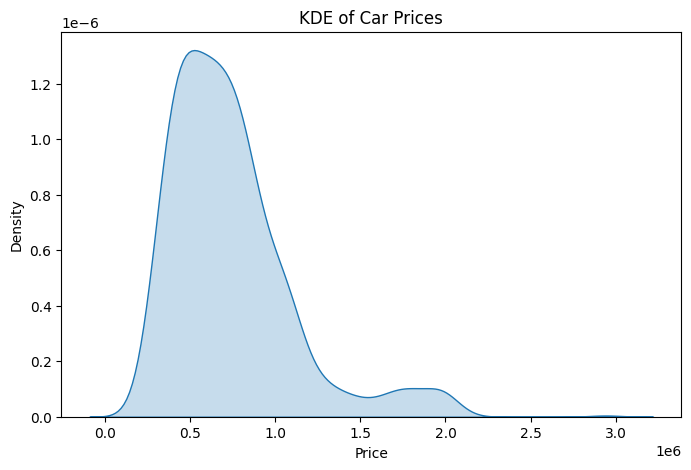

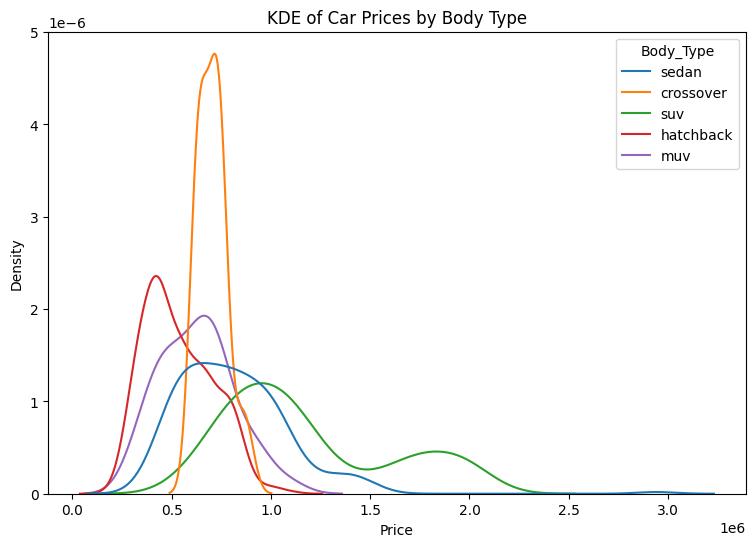

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cars = pd.read_csv('./data/cars_hw.csv')

print(cars["Price"].describe())

body_summary = cars.groupby("Body_Type")["Price"].describe()
print(body_summary)

plt.figure(figsize=(8,5))
sns.kdeplot(data=cars, x="Price", fill=True)
plt.title("KDE of Car Prices")
plt.show()

plt.figure(figsize=(9,6))
sns.kdeplot(data=cars, x="Price", hue="Body_Type", common_norm=False)
plt.title("KDE of Car Prices by Body Type")
plt.show()

SUV's are the most expnesive. Followed by sedans, corssovers, MUVs, and hatchbacks. SUV has the highest SD.

In [16]:
from sklearn.linear_model import LinearRegression

X = cars[["Seating_Capacity"]]
y = cars["Price"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 439032.0141018266
Slope: 59267.99803672175


Each extra seet costs a additional 59,268 rupees

In [17]:
X_cat = pd.get_dummies(cars["Seating_Capacity"].astype("category"), drop_first=True)
model_cat = LinearRegression()
model_cat.fit(X_cat, y)

print("Intercept:", model_cat.intercept_)
print(pd.DataFrame({
    "Seats": X_cat.columns,
    "Coefficient": model_cat.coef_
}))

Intercept: 188000.00000000314
  Seats   Coefficient
0     5  5.464839e+05
1     6  1.456000e+06
2     7  7.359487e+05
3     8  2.718000e+05


In [18]:
print(cars.groupby("Seating_Capacity")["Price"].mean())

Seating_Capacity
4    1.880000e+05
5    7.344839e+05
6    1.644000e+06
7    9.239487e+05
8    4.598000e+05
Name: Price, dtype: float64


5 seats costs around 734,484 a seven seater costs 923,949, eight seater is around 459,800. The differences here are not linear. Relationship is uneven.

In [19]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score

cars["Age"] = 2023 - cars["Make_Year"]

X_age = cars[["Age"]]
y = cars["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

results = []

for degree in range(1, 11):
    poly_model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )

    mse = -cross_val_score(
        poly_model,
        X_age,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    ).mean()

    results.append((degree, mse))

results_df = pd.DataFrame(results, columns=["Degree", "CV_MSE"])
print(results_df)
print("Best degree:", results_df.loc[results_df["CV_MSE"].idxmin(), "Degree"])

   Degree        CV_MSE
0       1  9.774576e+10
1       2  9.781532e+10
2       3  9.730408e+10
3       4  9.678539e+10
4       5  9.581629e+10
5       6  9.592259e+10
6       7  9.527092e+10
7       8  9.446040e+10
8       9  9.416477e+10
9      10  9.428010e+10
Best degree: 9


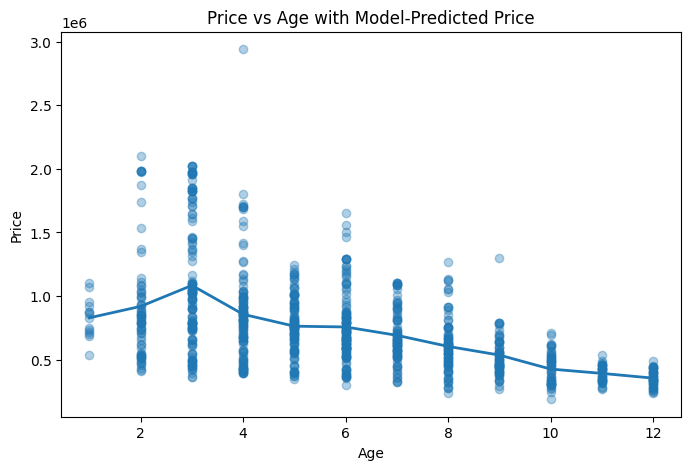

In [20]:
best_degree = 9

final_model = make_pipeline(
    PolynomialFeatures(best_degree, include_bias=False),
    LinearRegression()
)
final_model.fit(X_age, y)

age_grid = pd.DataFrame({"Age": np.arange(cars["Age"].min(), cars["Age"].max() + 1)})
predicted_prices = final_model.predict(age_grid)

plt.figure(figsize=(8,5))
plt.scatter(cars["Age"], cars["Price"], alpha=0.35)
plt.plot(age_grid["Age"], predicted_prices, linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model-Predicted Price")
plt.show()

Scatterplot here shows the new cars have higher prices than older clars. But theres variance at each age. The model shows that its a nonlinear pattern between age and price. The model only gets the broad trend it doesn't explain all the variation.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
